In [1]:
import matplotlib.pyplot as plt
import skimage
import os
from PIL import Image
import numpy as np
import random
from skimage.filters import threshold_otsu, threshold_local
from skimage.color import rgb2gray
import pandas as pd
import seaborn as sns

In [2]:
os.getcwd()

'c:\\Users\\Siema\\Documents\\ml\\projekt 2\\jellyfish_ML\\CLUSTERING'

In [3]:
df_embeddings = pd.read_csv(r"..\new_data\features\train_features.csv")

In [4]:
df_embeddings

,0,1,2,3,4,5,6,7,8,9,...,191,192,193,194,195,196,197,198,199,label
0,5.529281,5.476995,5.095528,-2.606911,3.709473,5.521223,4.666998,-4.709508,1.239683,-5.094215,...,-1.405778,0.287393,1.136826,-0.348106,-0.118046,0.292328,0.069080,-0.036712,0.548572,Moon_jellyfish
1,-0.449439,-1.665579,4.138653,-4.054792,-5.847390,3.665126,0.592320,2.558347,-1.867438,-1.536962,...,0.309409,0.130389,-0.371079,-0.622086,0.699570,-0.182567,-0.047691,-0.193775,-0.155612,compass_jellyfish
2,2.050851,-8.428734,-0.445970,0.384321,4.615688,0.859660,-3.321346,3.447272,-2.751952,1.137085,...,-0.062982,0.280984,-0.380643,-0.139765,0.459788,0.156531,-0.424835,0.458212,-0.349536,blue_jellyfish
3,6.250445,0.280575,7.725238,-0.084627,-1.376028,1.693741,-1.404230,2.227116,5.043908,5.133567,...,-0.338685,-0.605541,-1.116287,0.425685,-1.690431,0.401615,0.066426,-0.494735,-0.893614,blue_jellyfish
4,5.546583,5.778194,-1.941005,-3.316156,0.719191,2.321846,-3.538398,-3.466824,2.653350,-1.040555,...,-0.389394,-1.207337,0.517451,0.484081,-0.239926,-0.102592,0.631495,0.701369,-1.495694,Moon_jellyfish
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
778,-0.949504,-7.158218,-1.507189,-1.693069,-3.495238,-2.511450,5.074431,1.370732,6.902033,-1.503647,...,0.334268,-0.430193,0.656089,-0.627273,0.527458,-0.224733,-0.353620,0.002929,0.029773,lions_mane_jellyfish
779,-2.441665,-1.903469,-0.496063,2.540545,3.435913,5.259140,-1.624611,1.415278,-3.909711,-1.879944,...,-0.502198,-0.058826,0.353578,-0.427912,-0.401634,0.220697,0.498131,-0.913368,-0.048718,compass_jellyfish
780,2.970256,0.168088,3.205246,1.654348,3.369863,1.200398,-3.589286,-1.088812,-5.687056,-2.918817,...,1.649229,-0.504858,-0.017761,-0.278821,-0.353828,0.476544,0.966958,-0.279218,0.093379,blue_jellyfish
781,8.168258,-2.942810,-0.115453,1.627771,-1.106622,-7.429671,-1.450931,0.698465,-2.531385,3.971310,...,-0.989936,0.284967,-0.449238,-0.708116,-0.439643,-0.387548,-0.502036,-0.348488,-0.465440,Moon_jellyfish


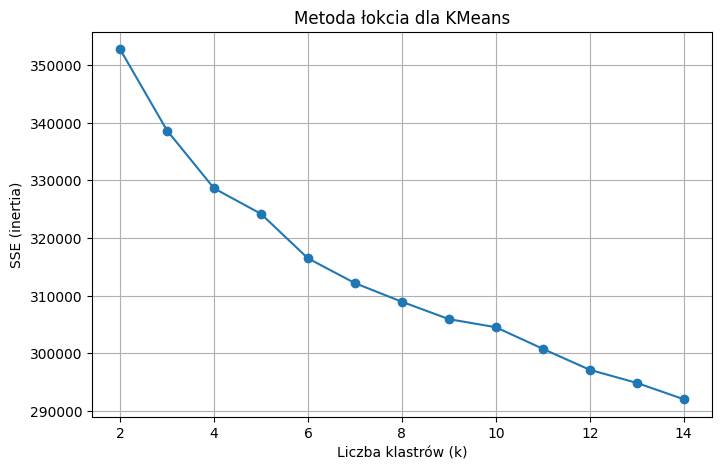

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = df_embeddings.drop(columns=['label'])
X.columns = X.columns.astype(str)

sse = []
k_range = range(2, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)  # inertia_ = suma odległości do centroidów

plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o')
plt.title("Metoda łokcia dla KMeans")
plt.xlabel("Liczba klastrów (k)")
plt.ylabel("SSE (inertia)")
plt.grid(True)
plt.show()

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd

# Zakładamy, że masz raw_df_embeddings z kolumną 'label'
X = df_embeddings.drop(columns=['label'])

# Zakres k
k_range = range(2, 15)

# Lista do wyników
results = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(X)

    silhouette = silhouette_score(X, cluster_labels)
    calinski = calinski_harabasz_score(X, cluster_labels)
    davies = davies_bouldin_score(X, cluster_labels)

    results.append({
        'k': k,
        'silhouette_score': silhouette,
        'calinski_harabasz_score': calinski,
        'davies_bouldin_score': davies
    })

# Wyniki jako DataFrame
metrics_df = pd.DataFrame(results)

# Sortowanie po silhouette score malejąco
metrics_df = metrics_df.sort_values(by='silhouette_score', ascending=False)

# Wyświetlenie
metrics_df

,k,silhouette_score,calinski_harabasz_score,davies_bouldin_score
4,6,0.053930,25.848390,3.758488
3,5,0.052514,26.947495,3.827968
2,4,0.051041,31.990175,3.689837
5,7,0.047696,23.588568,3.745689
1,3,0.044353,35.078460,3.608883
11,13,0.043858,16.157291,3.414128
10,12,0.043240,16.979107,3.597274
0,2,0.042263,36.208501,4.585827
7,9,0.041938,19.982347,3.639222
12,14,0.039825,15.613391,3.519197


- silhuette na <0,1> im więcej tym lepiej
- calinski_harabasz im więcej tym lepiej
- davies_bouldin_score im mniej tym lepiej, najlepiej niżej 1

In [7]:
metrics_df.loc[(metrics_df["k"] == 6 ) | (metrics_df["k"]==4),]

,k,silhouette_score,calinski_harabasz_score,davies_bouldin_score
4,6,0.053930,25.848390,3.758488
2,4,0.051041,31.990175,3.689837


4 i 6 najlepsze

In [8]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6, random_state=42)
y_pred = kmeans.fit_predict(df_embeddings.drop('label', axis=1))

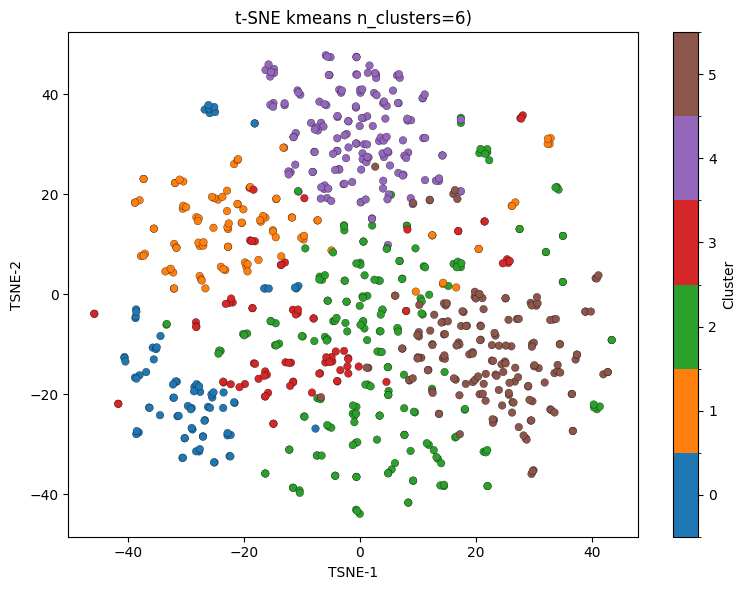

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.manifold import TSNE

def plot_tsne_clusters(y_pred, algorythm_name, n_clusters=4,df_embeddings=df_embeddings ,random_state=42, figsize=(8, 6), point_size=30):
    """
    Wygeneruj wykres t-SNE dla podanych embeddingów i etykiet klastrów.

    Parametry:
    ----------
    df_embeddings : pandas.DataFrame
        DataFrame zawierający kolumny embeddingów (np. wektory z ResNet). 
        Jeśli w DataFrame jest kolumna o nazwie 'label', zostanie ona automatycznie pominięta.
    y_pred : array-like (n_samples,)
        Tablica przewidzianych etykiet klastrów (wartości od 0 do n_clusters-1).
    n_clusters : int, opcjonalnie (domyślnie 4)
        Liczba klastrów (używana do wygenerowania odpowiedniej mapy kolorów).
    random_state : int, opcjonalnie (domyślnie 42)
        Ziarno losowości używane w TSNE, dla powtarzalności wyników.
    figsize : tuple, opcjonalnie (domyślnie (8, 6))
        Rozmiar figury w calach (szerokość, wysokość).
    point_size : int lub float, opcjonalnie (domyślnie 30)
        Rozmiar punktów na wykresie.

    Zwraca:
    -------
    None
        Funkcja jedynie wyświetla wykres; nie zwraca wartości.
    """

    # Sporządź macierz wejściową X: odłóż ewentualną kolumnę 'label', jeśli istnieje
    if 'label' in df_embeddings.columns:
        X = df_embeddings.drop(columns=['label']).values
    else:
        X = df_embeddings

    # Uruchom t-SNE, redukując do 2 wymiarów
    tsne = TSNE(n_components=2, random_state=random_state)
    X_2d = tsne.fit_transform(X)

    # Pobierz colormap "tab10" i wygeneruj dokładnie n_clusters kolorów
    base_cmap = plt.get_cmap('tab10')
    if n_clusters <= 10:
        colors = [base_cmap(i) for i in range(n_clusters)]
    else:
        # Jeśli klastrów jest więcej niż 10, ponownie użyj 'tab10' z indeksami modulo 10
        colors = [base_cmap(i % 10) for i in range(n_clusters)]
    cmap = ListedColormap(colors)

    # BoundaryNorm tak, aby wartości w {0,1,...,n_clusters-1} mapowały się na kolejne kolory
    norm = BoundaryNorm(boundaries=np.arange(-0.5, n_clusters, 1), ncolors=cmap.N)

    # Twórz wykres
    plt.figure(figsize=figsize)
    sc = plt.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=y_pred,
        cmap=cmap,
        norm=norm,
        s=point_size,
        edgecolor='k',
        linewidth=0.2
    )

    plt.title(f"t-SNE {algorythm_name} n_clusters={n_clusters})")
    plt.xlabel("TSNE-1")
    plt.ylabel("TSNE-2")

    # Dodaj dyskretną skalę kolorów z etykietami 0,1,...,n_clusters-1
    cbar = plt.colorbar(sc, boundaries=np.arange(-0.5, n_clusters, 1), ticks=np.arange(0, n_clusters))
    cbar.set_label('Cluster')

    plt.tight_layout()
    plt.show()

plot_tsne_clusters(y_pred, "kmeans", 6)

C:\Users\Siema\AppData\Local\Temp\ipykernel_26260\1306503900.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_pct = contingency_pct.applymap(lambda x: f"{x:.1f}%")


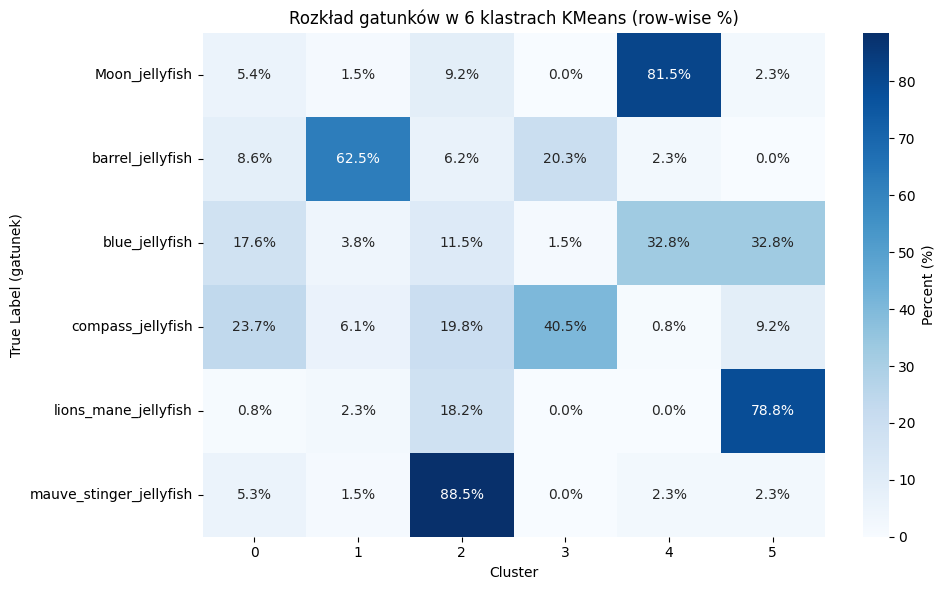

In [10]:
# Zakładamy, że masz kolumny: 'label' (gatunek) i 'cluster' (numer klastra)
def confusion_matrix(y_pred, algorythim_name,df_embeddings=df_embeddings):
    # 1) compute raw counts
    contingency_matrix = pd.crosstab(df_embeddings['label'], y_pred)

    # 2) convert to row‐wise percentages
    contingency_pct = contingency_matrix.div(contingency_matrix.sum(axis=1), axis=0) * 100

    # 3) build an annot matrix with “x.x%” strings
    annot_pct = contingency_pct.applymap(lambda x: f"{x:.1f}%")

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        contingency_pct,
        annot=annot_pct,       # show “12.3%” instead of raw counts
        fmt="",                # since annot is already strings with “%”
        cmap="Blues",
        cbar_kws={"label": "Percent (%)"}
    )
    plt.title(f"Rozkład gatunków w {len(np.unique(y_pred))} klastrach {algorythim_name} (row‐wise %)")
    plt.xlabel("Cluster")
    plt.ylabel("True Label (gatunek)")
    plt.tight_layout()
    plt.show()
confusion_matrix(y_pred,"KMeans")

In [11]:
from sklearn.metrics import adjusted_rand_score, v_measure_score, normalized_mutual_info_score, homogeneity_score, completeness_score, fowlkes_mallows_score
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

true = df_embeddings['label']
pred = y_pred # albo 'cluster_kmeans'

def metrics(true, pred, df_embeddings=df_embeddings):
    print("Adjusted Rand Index (ARI):", adjusted_rand_score(true, pred))
    print("V-measure:", v_measure_score(true, pred))
    print("NMI:", normalized_mutual_info_score(true, pred))
    print("Homogeneity:", homogeneity_score(true, pred))
    print("Completeness:", completeness_score(true, pred))
    print("Fowlkes-Mallows Score:", fowlkes_mallows_score(true, pred))
    print("-------------------------------------------------")
    print("Silhouette Score:", silhouette_score(df_embeddings.drop(columns=['label']), pred))
    print("Davies-Bouldin Index:", davies_bouldin_score(df_embeddings.drop(columns=['label']), pred))
    print("Calinski-Harabasz Score:", calinski_harabasz_score(df_embeddings.drop(columns=['label']), pred))


metrics(true, pred, df_embeddings)

Adjusted Rand Index (ARI): 0.37234535403690433
V-measure: 0.4301699407104453
NMI: 0.4301699407104453
Homogeneity: 0.4226682272557202
Completeness: 0.43794275360544843
Fowlkes-Mallows Score: 0.48327929255197954
-------------------------------------------------
Silhouette Score: 0.053930443628308934
Davies-Bouldin Index: 3.7584875540723104
Calinski-Harabasz Score: 25.848389604495324


In [12]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
y_pred = kmeans.fit_predict(df_embeddings.drop('label', axis=1))

C:\Users\Siema\AppData\Local\Temp\ipykernel_26260\1306503900.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_pct = contingency_pct.applymap(lambda x: f"{x:.1f}%")


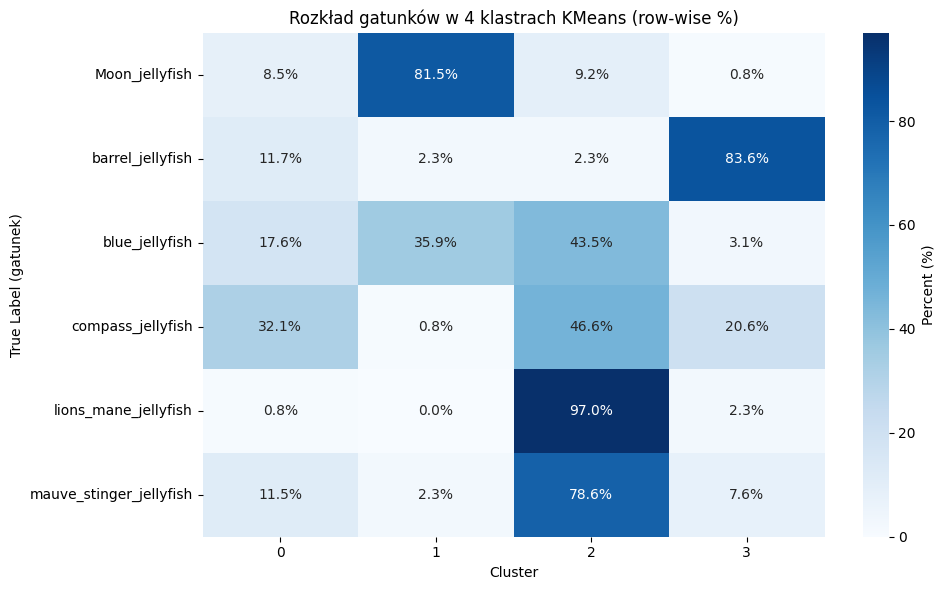

Adjusted Rand Index (ARI): 0.37234535403690433
V-measure: 0.4301699407104453
NMI: 0.4301699407104453
Homogeneity: 0.4226682272557202
Completeness: 0.43794275360544843
Fowlkes-Mallows Score: 0.48327929255197954
-------------------------------------------------
Silhouette Score: 0.053930443628308934
Davies-Bouldin Index: 3.7584875540723104
Calinski-Harabasz Score: 25.848389604495324


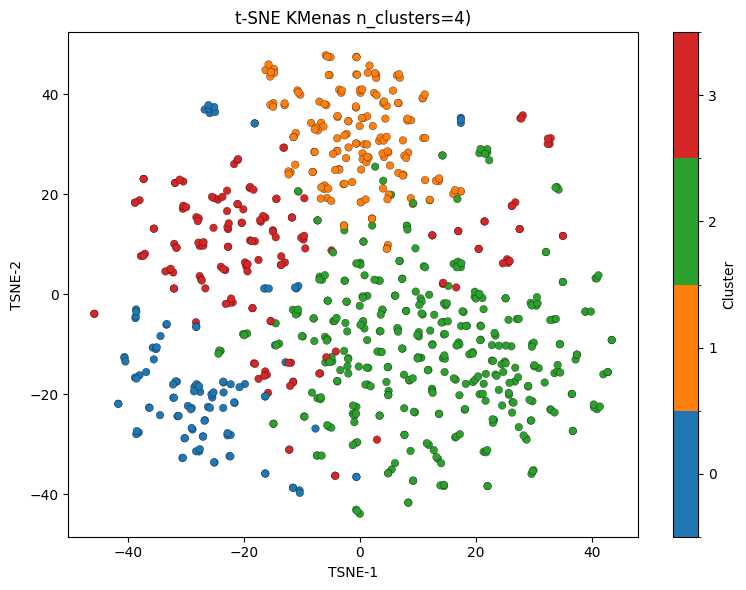

In [13]:
confusion_matrix(y_pred,"KMeans")
metrics(df_embeddings["label"], pred, df_embeddings)
plot_tsne_clusters(y_pred,"KMenas",4)

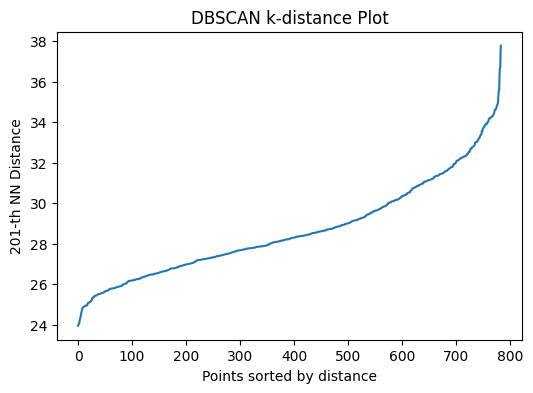

Contingency table (true vs. DBSCAN clusters):
col_0                      0
label                       
Moon_jellyfish           130
barrel_jellyfish         128
blue_jellyfish           131
compass_jellyfish        131
lions_mane_jellyfish     132
mauve_stinger_jellyfish  131

Adjusted Rand Index: 0.000
Cannot compute silhouette: only one (or zero) cluster present among non-noise points.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score

# 2) Prepare feature matrix
X = df_embeddings.drop("label",axis=1)

# 3) Find a good eps via k-distance plot
min_samples = 201
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X)
distances, _ = nbrs.kneighbors(X)
kth_distances = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(kth_distances)
plt.ylabel(f"{min_samples}-th NN Distance")
plt.xlabel("Points sorted by distance")
plt.title("DBSCAN k-distance Plot")
plt.show()

# 4) From the plot, pick an eps (e.g., 0.5)
eps_value = 32
db = DBSCAN(eps=eps_value, min_samples=min_samples, metric="euclidean")
y_pred = db.fit_predict(X)

# 5) Attach cluster labels


# 6) Evaluation: crosstab and ARI
crosstab = pd.crosstab(df_embeddings["label"], y_pred)
print("Contingency table (true vs. DBSCAN clusters):")
print(crosstab)

ari = adjusted_rand_score(df_embeddings["label"], y_pred)
print(f"\nAdjusted Rand Index: {ari:.3f}")

# 7) Silhouette (excluding noise)
mask = y_pred != -1
cluster_labels_non_noise = y_pred[mask]

# How many unique cluster labels (excluding –1)?
unique_labels = np.unique(cluster_labels_non_noise)

if unique_labels.shape[0] >= 2:
    sil_score = silhouette_score(X[mask], cluster_labels_non_noise)
    print(f"Silhouette Score (excluding noise): {sil_score:.3f}")
else:
    print("Cannot compute silhouette: only one (or zero) cluster present among non-noise points.")


In [15]:
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.model_selection import ParameterGrid
import pandas as pd
import numpy as np

# -------------------------------
# 1) Zdefiniuj siatkę parametrów
# -------------------------------
param_grid = {
    "eps":  [10, 20, 25, 30, 32, 35, 40],   # <- dobierz własny zakres
    "min_samples": [50, 100, 150, 201, 250] # <- j.w.
}

results = []  # będziemy tu zbierać metryki
X = df_embeddings.drop("label",axis=1)
# --------------------------------------------
# 2) Iteruj po siatce i oblicz metryki jakości
# --------------------------------------------
for params in ParameterGrid(param_grid):
    db = DBSCAN(**params, metric="euclidean")
    y_pred = db.fit_predict(X)

    # ARI (jeśli masz prawdziwe etykiety)
    ari = adjusted_rand_score(df_embeddings["label"], y_pred)

    # Silhouette — policz tylko, gdy >1 klaster (bez -1)
    mask = y_pred != -1
    unique_clusters = np.unique(y_pred[mask])
    if unique_clusters.size >= 2:
        sil = silhouette_score(X[mask], y_pred[mask])
    else:
        sil = np.nan  # brak sensownej wartości

    # policz udział punktów oznaczonych jako noise (przydaje się)
    noise_ratio = (y_pred == -1).mean()

    results.append({
        "eps": params["eps"],
        "min_samples": params["min_samples"],
        "ARI": ari,
        "silhouette": sil,
        "noise_ratio": noise_ratio
    })

# --------------------------------------------
# 3) Zamień wyniki na DataFrame i posortuj
# --------------------------------------------
grid_results = pd.DataFrame(results)
# Najpierw ARI (malejąco), potem silhouette (malejąco), potem najmniej noise
grid_results = grid_results.sort_values(
    by=["ARI", "silhouette", "noise_ratio"],
    ascending=[False, False, True]
)
print(grid_results.head(10))  # TOP-10 konfiguracji

# --------------------------------------------
# 4) Wybierz najlepszą konfigurację i trenuj model
# --------------------------------------------
best_params = grid_results.loc[0,["eps", "min_samples"]].astype(int).to_dict()
best_dbscan = DBSCAN(**best_params, metric="euclidean")
best_labels = best_dbscan.fit_predict(X)

print(f"\nWybrana konfiguracja: eps={best_params['eps']}, "
      f"min_samples={best_params['min_samples']}")


    eps  min_samples       ARI  silhouette  noise_ratio
14   25          250  0.027380         NaN     0.390805
13   25          201  0.025610         NaN     0.328225
12   25          150  0.022338         NaN     0.286079
11   25          100  0.013541         NaN     0.222222
10   25           50  0.012147         NaN     0.197957
19   30          250  0.000040         NaN     0.005109
15   30           50  0.000020         NaN     0.003831
16   30          100  0.000020         NaN     0.003831
17   30          150  0.000020         NaN     0.003831
18   30          201  0.000020         NaN     0.003831

Wybrana konfiguracja: eps=10, min_samples=50


dbscan niestesty nie działa nawet z gridsearch

In [16]:
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd

# Przygotowanie danych
X = df_embeddings.drop(columns=['label'])

results = []
for k in range(2, 15):
    agglo = AgglomerativeClustering(n_clusters=k, linkage='ward')
    cluster_labels = agglo.fit_predict(X)
    
    silhouette = silhouette_score(X, cluster_labels)
    calinski = calinski_harabasz_score(X, cluster_labels)
    davies = davies_bouldin_score(X, cluster_labels)
    
    results.append({
        'k': k,
        'silhouette_score': silhouette,
        'calinski_harabasz_score': calinski,
        'davies_bouldin_score': davies
    })

# DataFrame z wynikami
metrics_agglo_df = pd.DataFrame(results).sort_values(by='silhouette_score', ascending=False)
metrics_agglo_df = metrics_agglo_df.reset_index().drop("index",axis=1)
metrics_agglo_df

,k,silhouette_score,calinski_harabasz_score,davies_bouldin_score
0,5,0.044440,26.555855,4.053389
1,3,0.042881,32.146940,3.521335
2,9,0.041092,19.125077,3.480121
3,14,0.039953,15.475020,3.419653
4,4,0.039643,30.063738,3.828931
5,13,0.037030,16.004523,3.533938
6,8,0.036746,20.333836,3.812224
7,7,0.034636,21.796110,3.945005
8,11,0.034240,17.330909,3.431656
9,12,0.033434,16.636888,3.445314


Adjusted Rand Index (ARI): 0.32346767947112465
V-measure: 0.42118065291951895
NMI: 0.42118065291951895
Homogeneity: 0.3888481738932591
Completeness: 0.45937760980767783
Fowlkes-Mallows Score: 0.46324406361005677
-------------------------------------------------
Silhouette Score: 0.04443975364288017
Davies-Bouldin Index: 4.053389225352376
Calinski-Harabasz Score: 26.55585451835157


C:\Users\Siema\AppData\Local\Temp\ipykernel_26260\1306503900.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_pct = contingency_pct.applymap(lambda x: f"{x:.1f}%")


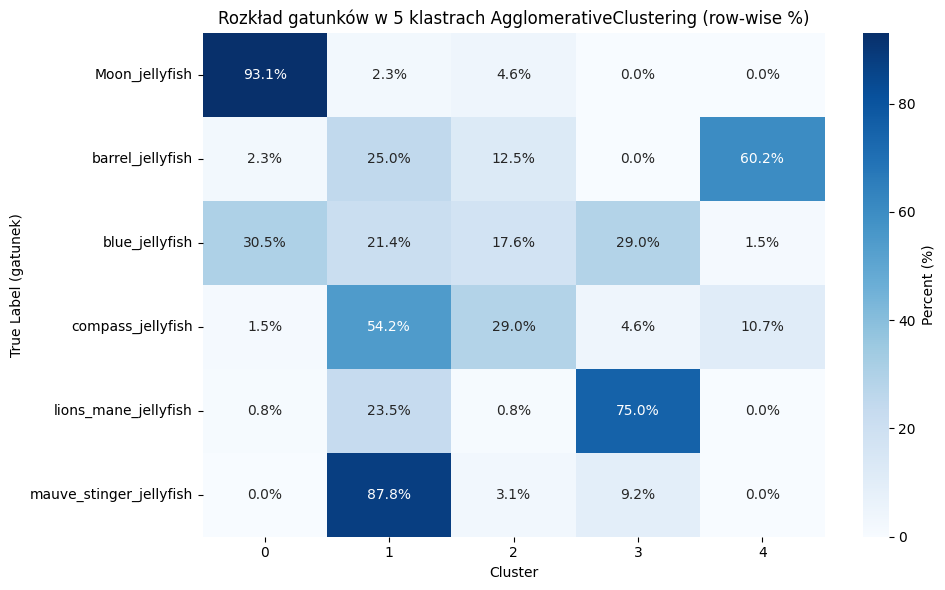

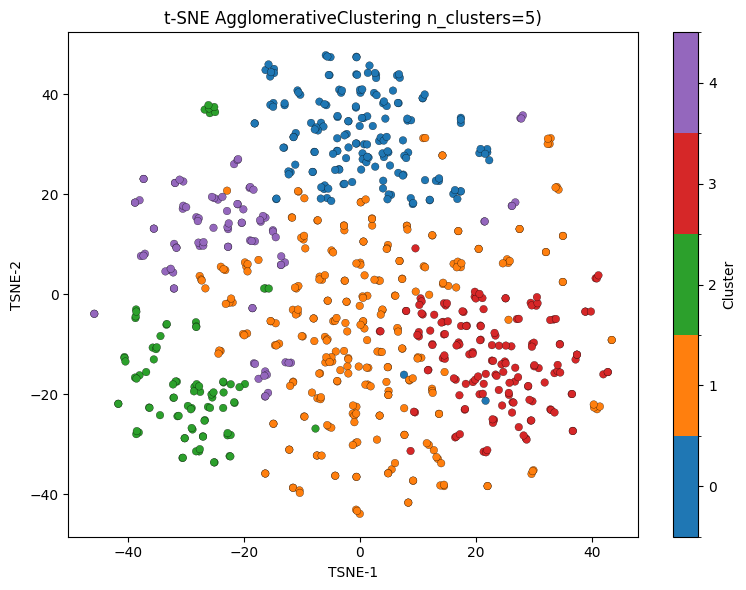

In [17]:
from sklearn.cluster import AgglomerativeClustering


X = df_embeddings.drop(columns=['label'],)
# Klasteryzacja hierarchiczna
agglo = AgglomerativeClustering(n_clusters=5, linkage='ward')
y_pred = agglo.fit_predict(X)

metrics(df_embeddings["label"], y_pred, df_embeddings)
confusion_matrix(y_pred, "AgglomerativeClustering")
plot_tsne_clusters(y_pred,"AgglomerativeClustering",5)

In [18]:
from sklearn.cluster import SpectralClustering
X = df_embeddings.drop(columns=['label'])

results = []
for k in range(2, 15):
    spectral = SpectralClustering(n_clusters=k,  affinity='nearest_neighbors', random_state=42)
    cluster_labels = spectral.fit_predict(X)
    
    silhouette = silhouette_score(X, cluster_labels)
    calinski = calinski_harabasz_score(X, cluster_labels)
    davies = davies_bouldin_score(X, cluster_labels)
    
    results.append({
        'k': k,
        'silhouette_score': silhouette,
        'calinski_harabasz_score': calinski,
        'davies_bouldin_score': davies
    })

# DataFrame z wynikami
metrics_agglo_df = pd.DataFrame(results).sort_values(by='silhouette_score', ascending=False)
metrics_agglo_df = metrics_agglo_df.reset_index().drop("index",axis=1)
metrics_agglo_df

,k,silhouette_score,calinski_harabasz_score,davies_bouldin_score
0,2,0.083149,24.652167,2.929880
1,4,0.051951,29.184042,3.893247
2,3,0.049912,31.583714,3.375257
3,14,0.046670,15.507378,3.110588
4,13,0.044250,15.564869,3.204776
5,9,0.043292,18.685024,3.431393
6,7,0.041554,21.716791,3.538817
7,8,0.041208,20.211111,3.558575
8,12,0.040979,16.158118,3.233774
9,5,0.039147,25.136063,3.692845


Adjusted Rand Index (ARI): 0.008346050798395396
V-measure: 0.059486140077905376
NMI: 0.059486140077905376
Homogeneity: 0.03428532260834826
Completeness: 0.22450331329415407
Fowlkes-Mallows Score: 0.38473284665691654
-------------------------------------------------
Silhouette Score: 0.08314854921054995
Davies-Bouldin Index: 2.9298795711454866
Calinski-Harabasz Score: 24.652167252892944


C:\Users\Siema\AppData\Local\Temp\ipykernel_26260\1306503900.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_pct = contingency_pct.applymap(lambda x: f"{x:.1f}%")


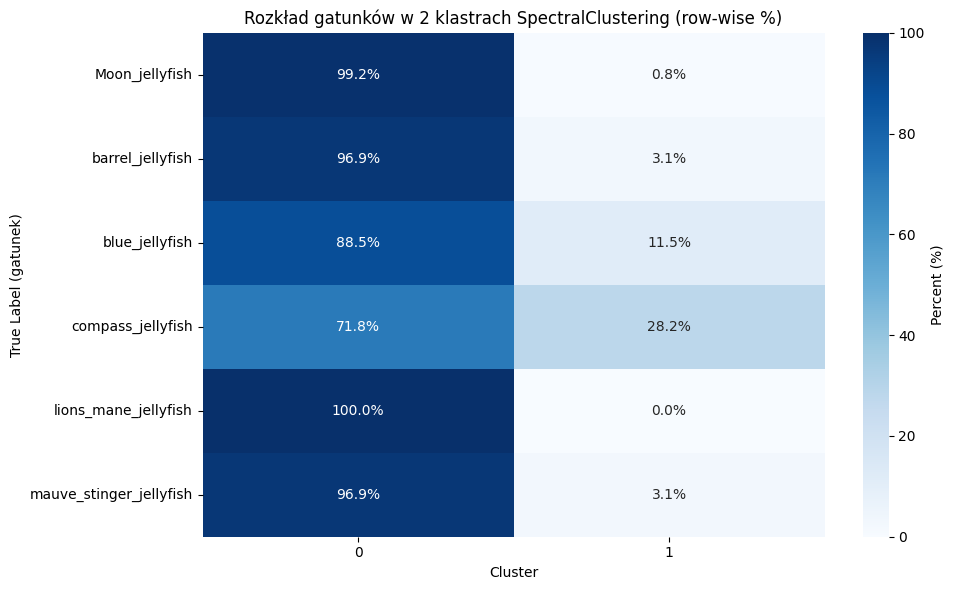

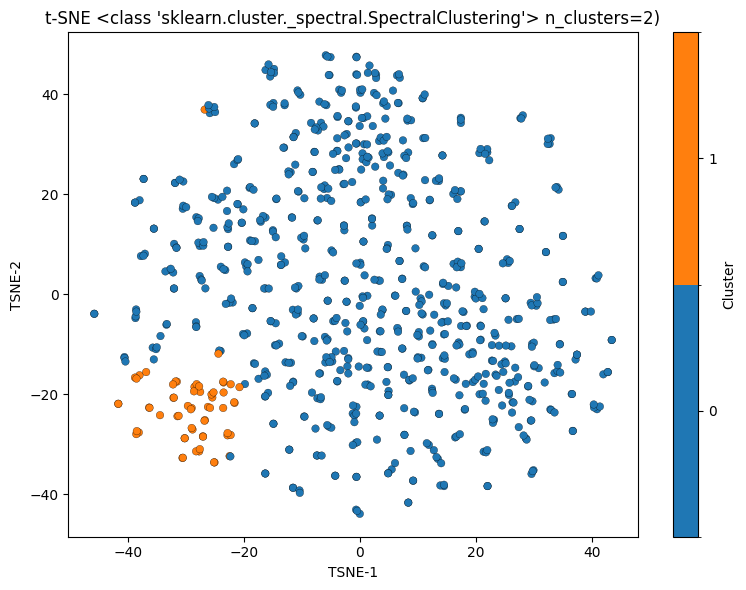

In [19]:

X = df_embeddings.drop(columns=['label'])
spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=42)
y_pred = spectral.fit_predict(X)

metrics(df_embeddings["label"],y_pred,df_embeddings)
confusion_matrix(y_pred,"SpectralClustering")
plot_tsne_clusters(y_pred, SpectralClustering,2)

Adjusted Rand Index (ARI): 0.293393793141644
V-measure: 0.410681265552726
NMI: 0.41068126555272594
Homogeneity: 0.34547179340145967
Completeness: 0.5062357033724292
Fowlkes-Mallows Score: 0.47616328757216164
-------------------------------------------------
Silhouette Score: 0.05195134521095033
Davies-Bouldin Index: 3.8932467818414853
Calinski-Harabasz Score: 29.184042496139558


C:\Users\Siema\AppData\Local\Temp\ipykernel_26260\1306503900.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_pct = contingency_pct.applymap(lambda x: f"{x:.1f}%")


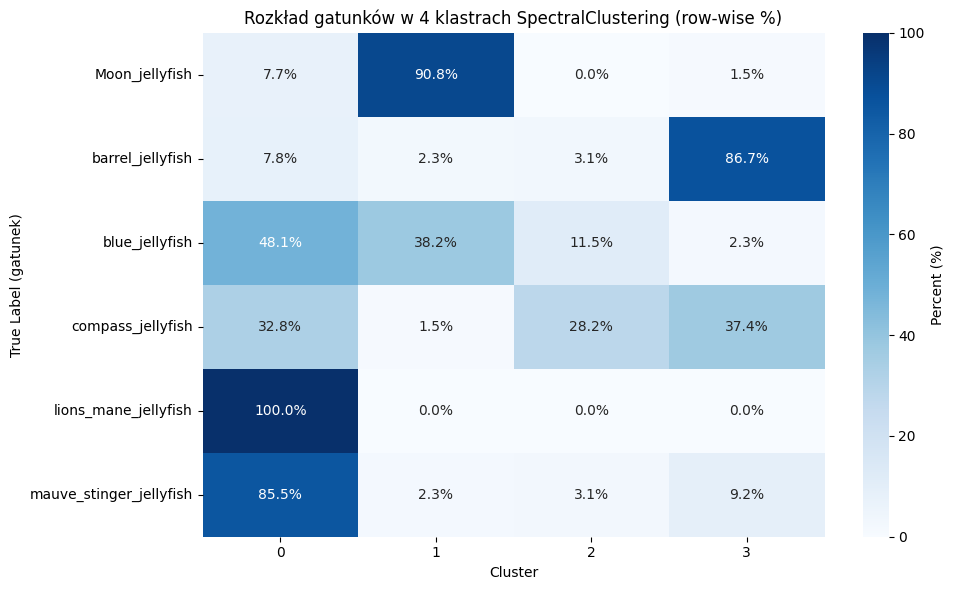

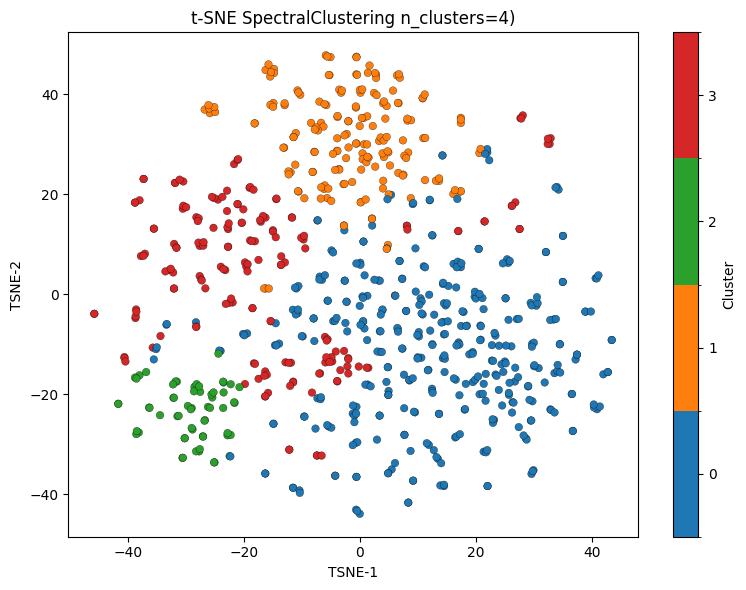

In [20]:
X = df_embeddings.drop(columns=['label'])
spectral = SpectralClustering(n_clusters=4, affinity='nearest_neighbors', random_state=42)
y_pred = spectral.fit_predict(X)

metrics(df_embeddings["label"],y_pred,df_embeddings)
confusion_matrix(y_pred,"SpectralClustering")
plot_tsne_clusters(y_pred, "SpectralClustering",4)

In [21]:
from sklearn.mixture import GaussianMixture
X = df_embeddings.drop(columns=['label'])

results = []
for k in range(2, 15):
    model = GaussianMixture(n_components=k, random_state=42)
    cluster_labels = model.fit_predict(X)
    
    silhouette = silhouette_score(X, cluster_labels)
    calinski = calinski_harabasz_score(X, cluster_labels)
    davies = davies_bouldin_score(X, cluster_labels)
    
    results.append({
        'k': k,
        'silhouette_score': silhouette,
        'calinski_harabasz_score': calinski,
        'davies_bouldin_score': davies
    })

# DataFrame z wynikami
metrics_agglo_df = pd.DataFrame(results).sort_values(by='silhouette_score', ascending=False)
metrics_agglo_df = metrics_agglo_df.reset_index().drop("index",axis=1)
metrics_agglo_df

,k,silhouette_score,calinski_harabasz_score,davies_bouldin_score
0,6,0.053930,25.848390,3.758488
1,5,0.052514,26.947495,3.827968
2,4,0.051041,31.990175,3.689837
3,7,0.047696,23.588568,3.745689
4,3,0.044353,35.078460,3.608883
5,13,0.043858,16.157291,3.414128
6,12,0.043240,16.979107,3.597274
7,2,0.042263,36.208501,4.585827
8,9,0.041938,19.982347,3.639222
9,14,0.039825,15.613391,3.519197


Adjusted Rand Index (ARI): 0.37234535403690433
V-measure: 0.4301699407104453
NMI: 0.4301699407104453
Homogeneity: 0.4226682272557202
Completeness: 0.43794275360544843
Fowlkes-Mallows Score: 0.48327929255197954
-------------------------------------------------
Silhouette Score: 0.053930443628308934
Davies-Bouldin Index: 3.7584875540723104
Calinski-Harabasz Score: 25.848389604495324


C:\Users\Siema\AppData\Local\Temp\ipykernel_26260\1306503900.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_pct = contingency_pct.applymap(lambda x: f"{x:.1f}%")


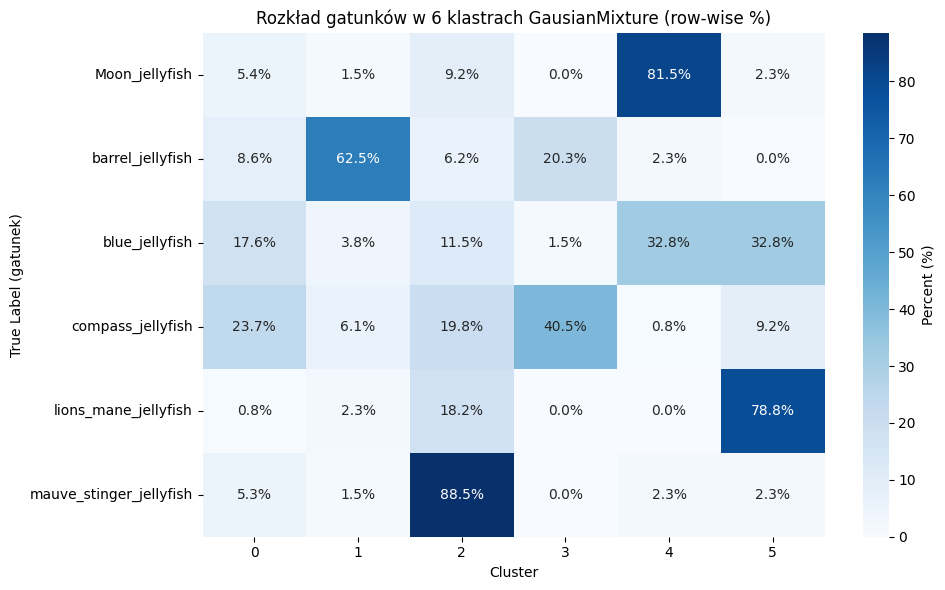

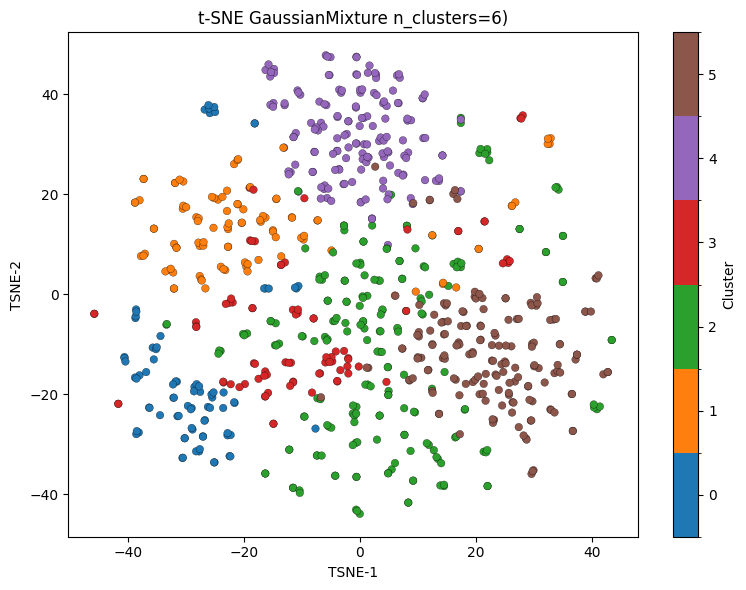

In [22]:
X = df_embeddings.drop(columns=['label'])

gmm = GaussianMixture(n_components=6, random_state=42)
y_pred = gmm.fit_predict(X)
metrics(df_embeddings["label"],y_pred)
confusion_matrix(y_pred,"GausianMixture")
plot_tsne_clusters(y_pred, "GaussianMixture", 6)